In [11]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

In [12]:
os.makedirs("Figures", exist_ok=True)

In [13]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


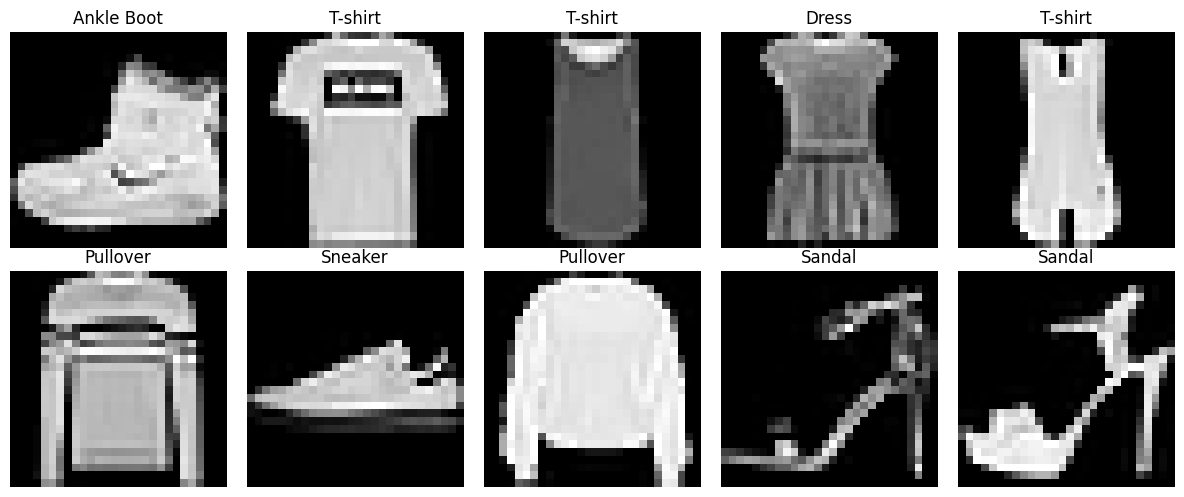

In [14]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Figures/sample_images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

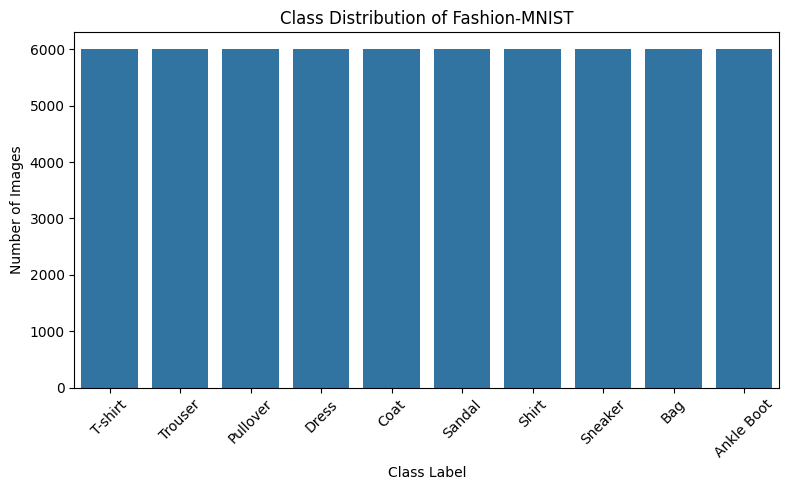

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train)

plt.title("Class Distribution of Fashion-MNIST")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")

plt.xticks(
    ticks=range(10),
    labels=class_names,
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "Figures/class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [16]:
print("Before Preprocessing")

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("\nAfter Preprocessing")

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)

print("Training Labels Shape :", y_train_cat.shape)
print("Testing Labels Shape  :", y_test_cat.shape)

Before Preprocessing
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)

After Preprocessing
Training Images Shape : (60000, 784)
Testing Images Shape  : (10000, 784)
Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


In [18]:
baseline_model = Sequential()

baseline_model.add(Dense(
    128,
    activation="relu",
    input_shape=(784,)
))

baseline_model.add(Dense(
    64,
    activation="relu"
))

baseline_model.add(Dense(
    10,
    activation="softmax"
))

baseline_model.summary()

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
start_time = time.time()

history = baseline_model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

baseline_training_time = time.time() - start_time

print(f"\nTraining Time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8166 - loss: 0.5169 - val_accuracy: 0.8367 - val_loss: 0.4337
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8616 - loss: 0.3821 - val_accuracy: 0.8528 - val_loss: 0.4093
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8743 - loss: 0.3448 - val_accuracy: 0.8757 - val_loss: 0.3496
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8835 - loss: 0.3164 - val_accuracy: 0.8756 - val_loss: 0.3430
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8879 - loss: 0.2997 - val_accuracy: 0.8739 - val_loss: 0.3553
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8954 - loss: 0.2817 - val_accuracy: 0.8811 - val_loss: 0.3364
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8992 - loss: 0.2692 - val_accuracy: 0.8823 - val_loss: 0.3326
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9034 - loss: 0.2575 -

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


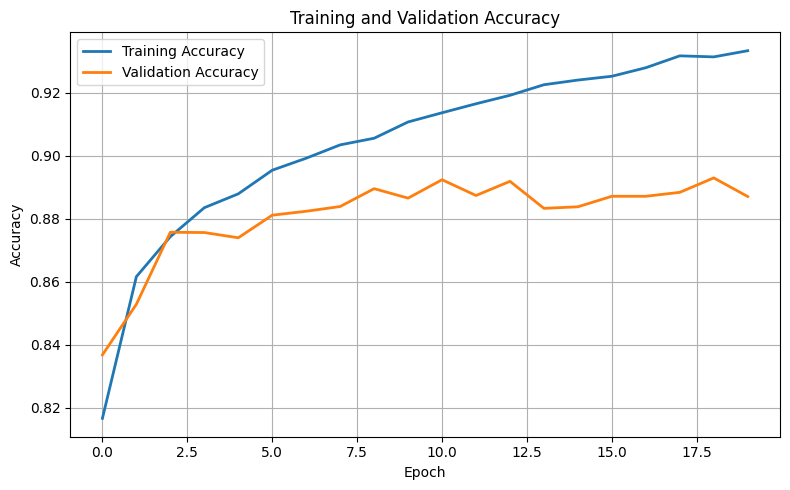

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/training_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


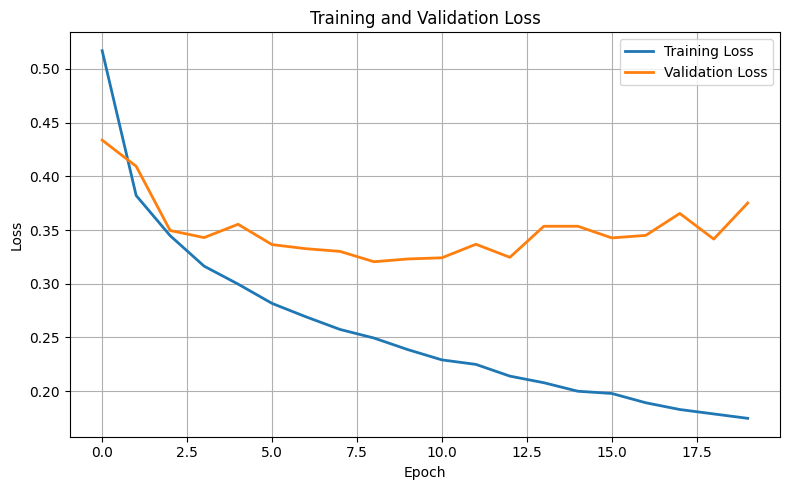

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/training_validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [23]:
y_pred_prob = baseline_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

baseline_accuracy = accuracy_score(y_test, y_pred)

baseline_precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

baseline_recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Baseline Model Performance")
print("-" * 35)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Baseline Model Performance
-----------------------------------
Accuracy  : 0.8818
Precision : 0.8822
Recall    : 0.8818
F1-Score  : 0.8813
              precision    recall  f1-score   support

     T-shirt       0.87      0.77      0.82      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.82      0.75      0.78      1000
       Dress       0.86      0.91      0.88      1000
        Coat       0.78      0.85      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.70      0.71      0.70      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.95      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



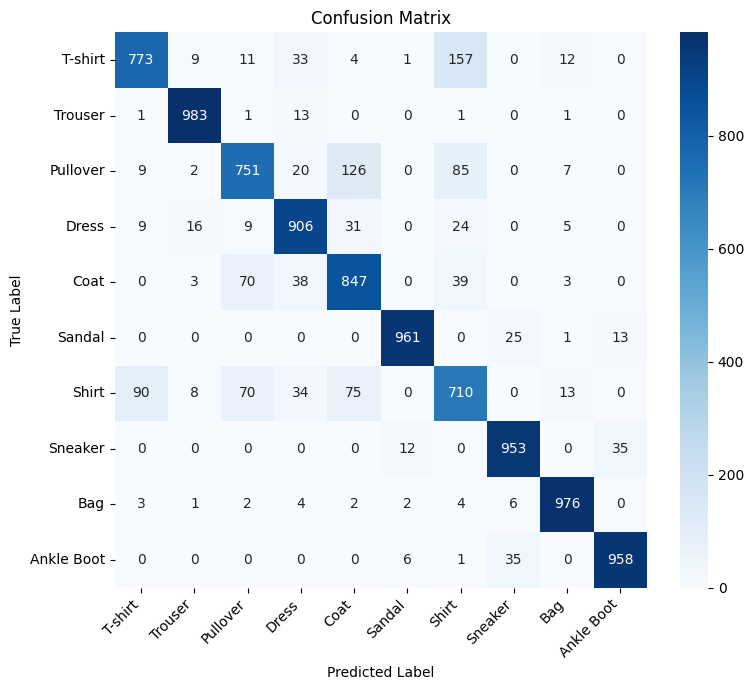

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Figures/confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [25]:
def create_model(
    hidden_layers=2,
    neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0
):

    model = Sequential()

    model.add(Dense(
        neurons,
        activation=activation,
        input_shape=(784,)
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):

        model.add(Dense(
            neurons,
            activation=activation
        ))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(
        10,
        activation="softmax"
    ))

    if optimizer.lower() == "adam":
        opt = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer.lower() == "sgd":
        opt = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:
        opt = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [26]:
mlp = KerasClassifier(
    model=create_model,
    verbose=0
)

param_dist = {

    "model__hidden_layers": [1, 2, 3],

    "model__neurons": [32, 64, 128, 256],

    "model__learning_rate": [0.1, 0.01, 0.001],

    "model__optimizer": [
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__activation": [
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate": [
        0.0,
        0.2,
        0.5
    ],

    "batch_size": [
        16,
        32,
        64,
        128
    ],

    "epochs": [
        10,
        20,
        30
    ]
}

In [27]:
random_search = RandomizedSearchCV(

    estimator=mlp,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

In [ ]:
start_time = time.time()

random_search.fit(
    X_train,
    y_train_cat
)

optimization_time = time.time() - start_time

print(f"\nOptimization Time: {optimization_time:.2f} seconds")

In [ ]:
# ================================
# Best Hyperparameters
# ================================

print("="*60)
print("BEST HYPERPARAMETERS")
print("="*60)

print(random_search.best_params_)
print("\nBest Cross Validation Accuracy:",
      random_search.best_score_)

In [ ]:
# ================================
# Train Optimized Model
# ================================

best = random_search.best_params_

optimized_model = create_model(
    hidden_layers=best["model__hidden_layers"],
    neurons=best["model__neurons"],
    learning_rate=best["model__learning_rate"],
    optimizer=best["model__optimizer"],
    activation=best["model__activation"],
    dropout=best["model__dropout"]
)

import time

start = time.time()

optimized_history = optimized_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=best["epochs"],
    batch_size=best["batch_size"],
    verbose=1
)

optimized_training_time = time.time() - start

print(f"\nTraining Time : {optimized_training_time:.2f} seconds")

In [ ]:
# ================================
# Evaluation
# ================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

pred_prob = optimized_model.predict(X_test)

pred = pred_prob.argmax(axis=1)

accuracy_opt = accuracy_score(y_test, pred)
precision_opt = precision_score(
    y_test,
    pred,
    average="weighted"
)
recall_opt = recall_score(
    y_test,
    pred,
    average="weighted"
)
f1_opt = f1_score(
    y_test,
    pred,
    average="weighted"
)

print("\nOptimized Model Accuracy :", accuracy_opt)
print("Optimized Model Precision:", precision_opt)
print("Optimized Model Recall   :", recall_opt)
print("Optimized Model F1 Score :", f1_opt)

In [ ]:
print(classification_report(y_test, pred))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Optimized Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(results)+1),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("Candidate")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(6,5))

models = ["Baseline", "Optimized"]

scores = [accuracy, accuracy_opt]

plt.bar(models, scores)

plt.ylim(0.8,1.0)

plt.ylabel("Accuracy")

plt.title("Best Model Accuracy Comparison")

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time"
    ],

    "Baseline":[
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ],

    "Optimized":[
        accuracy_opt,
        precision_opt,
        recall_opt,
        f1_opt,
        optimized_training_time
    ]

})

comparison

# XOR

In [ ]:
# XOR Dataset

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# XOR labels

y = np.array([
    0,
    1,
    1,
    0
])

learning_rate = 0.1

weights = np.zeros(2)

bias = 0

epochs = 10

def step(z):
    if z >= 0:
        return 1
    return 0

In [ ]:
def plot_boundary(weights, bias, epoch):

    plt.figure(figsize=(5,5))

    for i in range(len(X)):
        if y[i]==0:
            plt.scatter(
                X[i][0],
                X[i][1],
                color='red',
                s=120,
                label='Class 0' if i==0 else ""
            )
        else:
            plt.scatter(
                X[i][0],
                X[i][1],
                color='blue',
                s=120,
                label='Class 1' if i==1 else ""
            )

    x = np.linspace(-0.5,1.5,100)

    if weights[1]!=0:
        y_line = -(weights[0]*x+bias)/weights[1]
        plt.plot(x,y_line,'k',linewidth=2)

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.grid(True)

    plt.title(f"Decision Boundary After Update {epoch}")

    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.legend()

    plt.show()

In [ ]:
update = 1

for epoch in range(epochs):

    print("="*50)
    print("Epoch",epoch+1)
    print("="*50)

    error_count = 0

    for i in range(len(X)):

        net = np.dot(X[i],weights)+bias

        prediction = step(net)

        error = y[i]-prediction

        if error!=0:

            weights = weights + learning_rate*error*X[i]

            bias = bias + learning_rate*error

            error_count += 1

            print("Update",update)

            print("Weights :",weights)

            print("Bias :",bias)

            plot_boundary(weights,bias,update)

            update += 1

    if error_count==0:

        print("Converged Successfully")

        break

print("\nFinal Weights :",weights)

print("Final Bias :",bias)

In [ ]:
print("Predictions")

for i in range(len(X)):

    pred = step(np.dot(X[i],weights)+bias)

    print(X[i],"->",pred)